# Introduction

This notebook provides code to fit the NGA W3 model of Kuehn et al (2027).
All relevant functions are in package 'ngaw3_kuehnetal27'.
In this notbook, we load the data, select a subset, and fit the model with SVI.

In [3]:
# install ngaw3_kuehnetal27
!pip install ngaw3_kuehnetal27@git+https://github.com/nikuehn/ngaw3_kuehnetal27

Obtaining file:///content/drive/MyDrive/NGAW3/ngaw3_kuehnetal27
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ngaw3_kuehnetal27 (pyproject.toml) ... done
  Created wheel for ngaw3_kuehnetal27: filename=ngaw3_kuehnetal27-0.1.0-0.editable-py3-none-any.whl size=1392 sha256=8ceb769829fc2944b2ca2f0b8cf36ce0e72d916c7d1d7b6f7a0b2696e1fb59c6
  Stored in directory: /tmp/pip-ephem-wheel-cache-wdq3nssr/wheels/fe/9d/79/32222f4a2c22eec0b13893faf431d0a1bdec3113fc482c2761
Successfully built ngaw3_kuehnetal27


In [5]:
import pandas as pd
import numpy as np

import os

import jax
import jax.numpy as jnp

from plotnine import *
from matplotlib import rc

import ngaw3_kuehnetal27
from ngaw3_kuehnetal27.plotting import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

We save results and plots in google drive.
Change path to your needs.

In [6]:
dir_base = '/content/drive/MyDrive/NGAW3/'
dir_results = os.path.join(dir_base, 'RESULTS', 'spectrum_eas2')
if not os.path.exists(dir_results):
    os.makedirs(dir_results)

dir_plot = os.path.join(dir_results, 'plots')
if not os.path.exists(dir_plot):
    os.makedirs(dir_plot)

# Data

In [7]:
from ngaw3_kuehnetal27.data_loading import load_data, prepare_data
from ngaw3_kuehnetal27.utils import results_data_path

The following loads motion ids of outlirs.
These are records for which the absolute value of the single-site residual $\delta WS$ is largr than 4, from a fit with independent coefficients for each frequency.

In [8]:
df = pd.read_csv(results_data_path('eas/outlier_ids_dWS_sep.csv'))
outlier_ids = df['motion_id'].to_list()

In [9]:
date_string = '20250919'
flatfile_path = os.path.join(dir_base, 'DATA',f'NGA_West3_EAS_Flatfile_{date_string}.csv')

data_selected, frequencies_used, frequencies_used_names = load_data(flatfile_path,
                                                                    region="WUS",
                                                                    rrup_max=300,
                                                                    outlier_ids=outlier_ids)
data_selected_gl, _, _ = load_data(flatfile_path, region="Global",
                                   frequencies=frequencies_used, rrup_max=300,
                                   outlier_ids=outlier_ids)


data_used, data_eq, data_stat = prepare_data(frequencies_used_names, data_selected, n_rec_eq=1000)
data_used_gl, data_eq_gl, data_stat_gl = prepare_data(frequencies_used_names, data_selected_gl, n_rec_eq=1000)

/content/drive/MyDrive/NGAW3/ngaw3_kuehnetal27/src/ngaw3_kuehnetal27/data_loading.py:99: DtypeWarning: Columns (6,7,15,37,68,70,71,83,91,92,93,94,95,96,118,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
/content/drive/MyDrive/NGAW3/ngaw3_kuehnetal27/src/ngaw3_kuehnetal27/data_loading.py:99: DtypeWarning: Columns (6,7,15,37,68,70,71,83,91,92,93,94,95,96,118,137,138) have mixed types. Specify dtype option on import or set low_memory=False.


/tmp/ipykernel_1284/118058244.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1284/118058244.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/mag_dist_sep.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning:

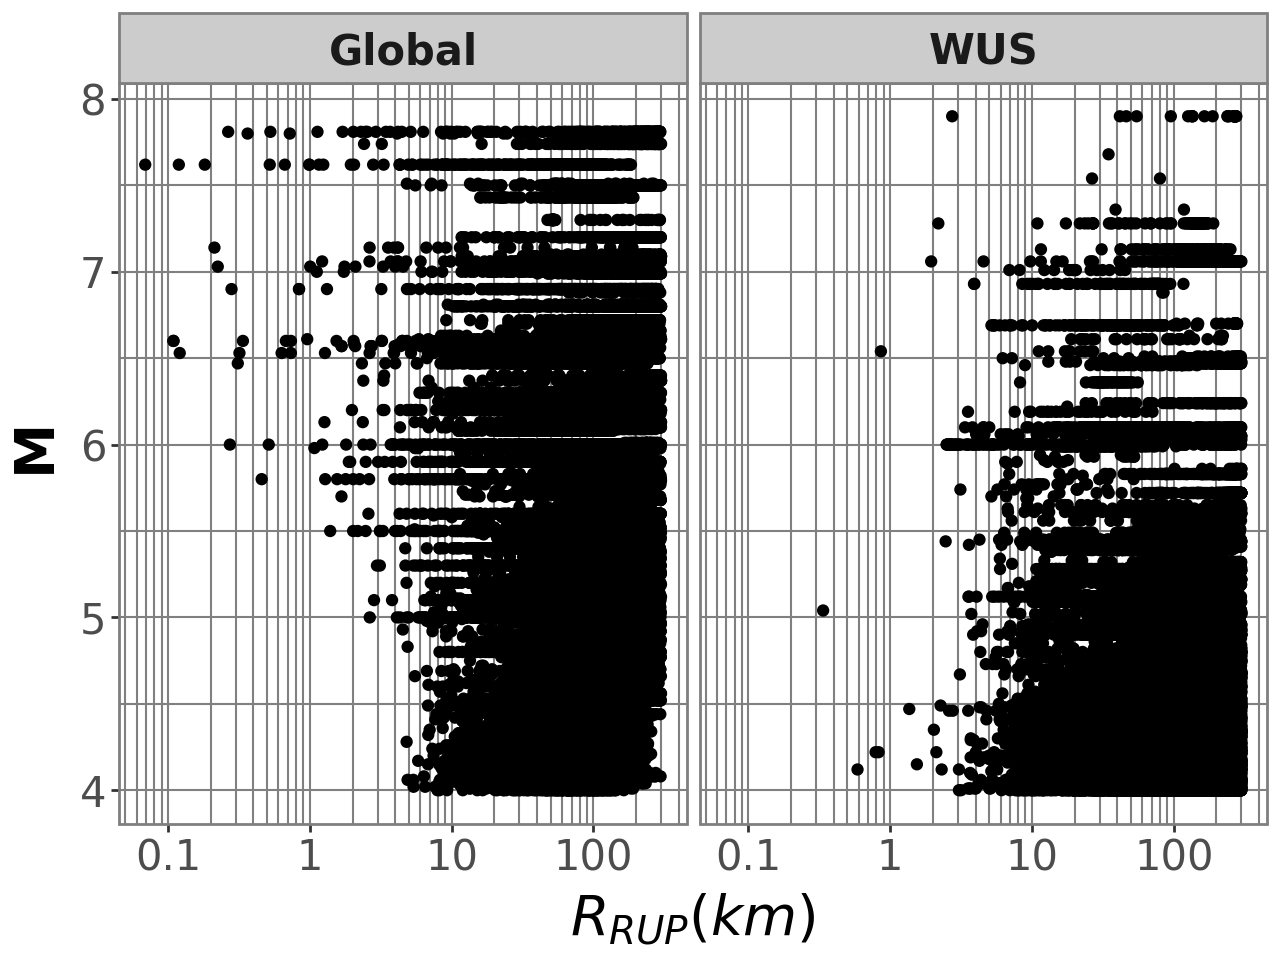

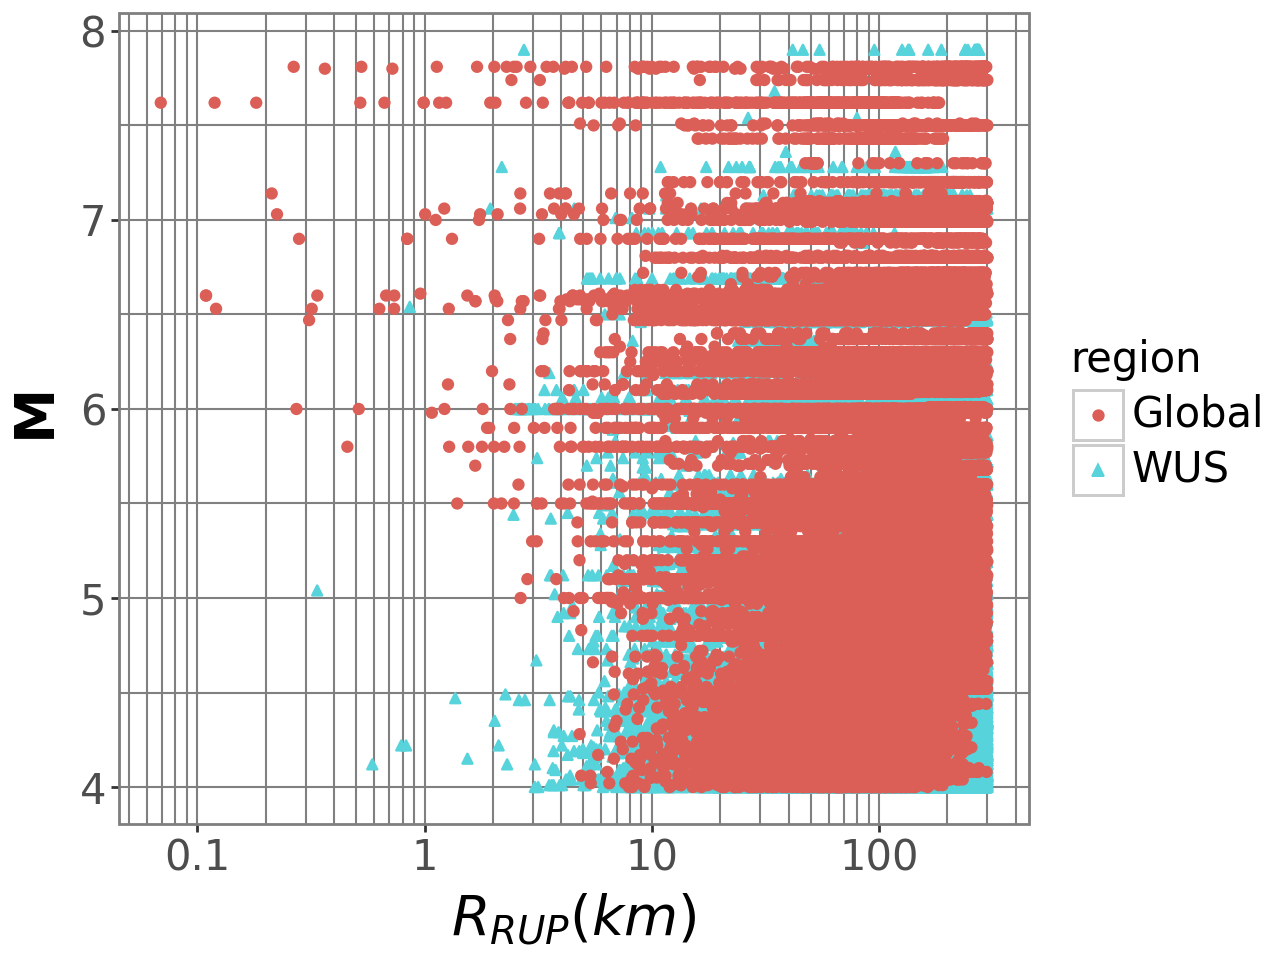

In [ ]:
def plot_mag_dist(data_used, data_used_gl):
    df1 = data_used[['magnitude', 'rrup']]
    df1['region'] = 'WUS'

    df2 = data_used_gl[['magnitude', 'rrup']]
    df2['region'] = 'Global'

    df = pd.concat([df1, df2])

    pl = (ggplot(df, aes(x = 'rrup', y = 'magnitude')) +
          geom_point(raster=True) +
          facet_wrap('~region') +
          labs(y = r'$\mathbf{M}$', x = r'$R_{RUP} (km)$') +
          scale_x_log10(breaks = log_breaks, minor_breaks=log_minor_breaks) +
          custom_theme)

    pl2 = (ggplot(df, aes(x = 'rrup', y = 'magnitude', color = 'region', shape = 'region')) +
           geom_point(raster=True) +
           labs(y = r'$\mathbf{M}$', x = r'$R_{RUP} (km)$') +
           scale_x_log10(breaks = log_breaks, minor_breaks=log_minor_breaks) +
           custom_theme)
    return pl, pl2

pl, pl2 = plot_mag_dist(data_used, data_used_gl)

# ggsave(pl, os.path.join(dir_plot, 'mag_dist_sep.pdf'),
#                         width = 2 * fig_width, height = fig_ratio * fig_width, dpi = 600)
# ggsave(pl2, os.path.join(dir_plot, 'mag_dist_comb.pdf'),
#                         width = fig_width, height = fig_ratio * fig_width, dpi = 600)
pl.show()
pl2.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/scatter_data.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 63425 rows containing missing values.
/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 63425 rows containing missing values.


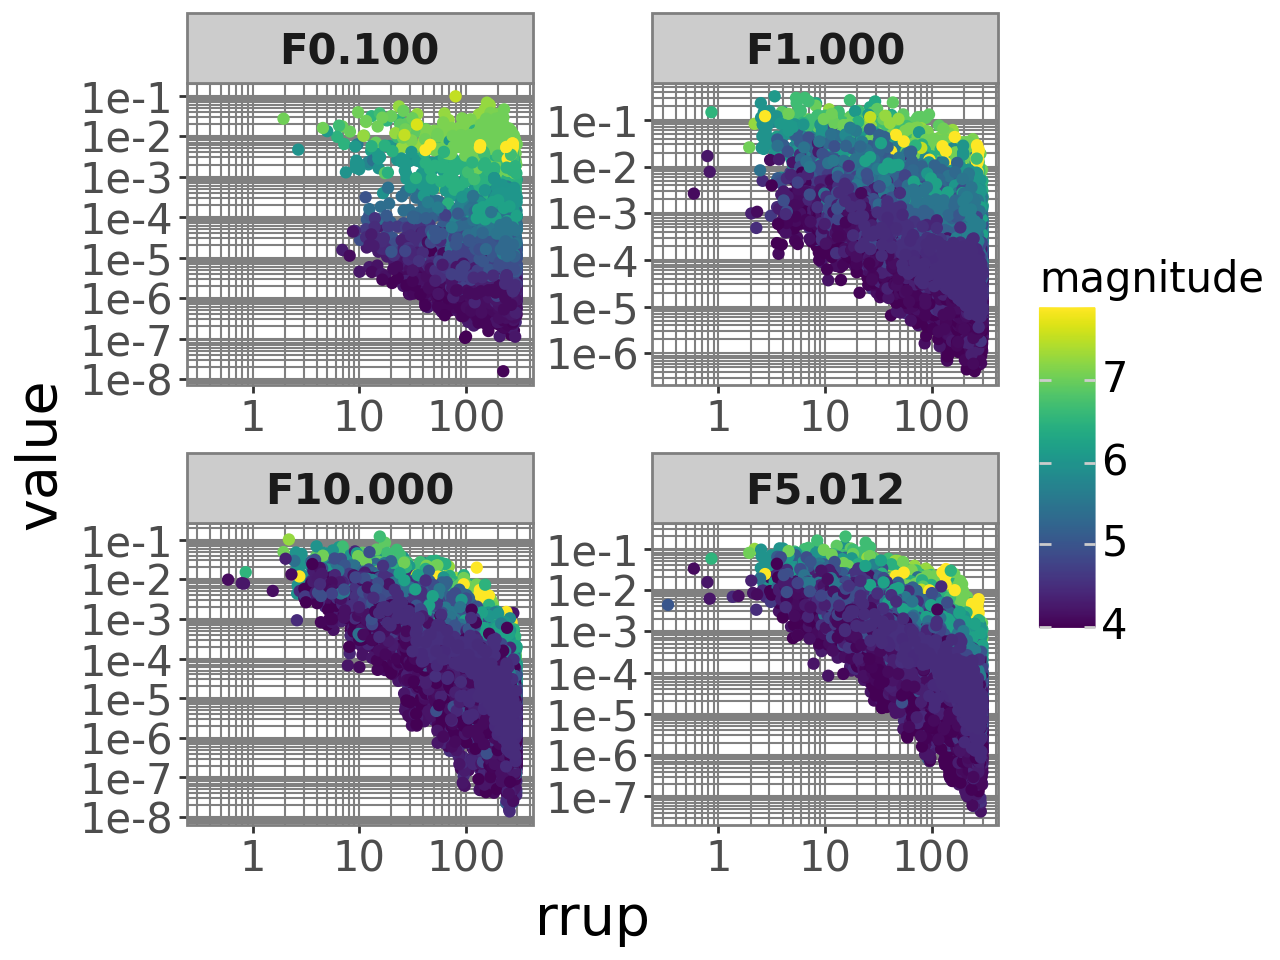

In [ ]:
frequencies_plot = ['F0.100', 'F1.000', 'F5.012', 'F10.000']
df = pd.melt(data_selected, id_vars=['magnitude', 'rrup'], value_vars=frequencies_plot)

pl = (ggplot(df, aes(x = 'rrup', y = 'value', color = 'magnitude')) +
      geom_point(raster=True) +
      facet_wrap('~variable', scales = 'free') +
      scale_x_log10(breaks = log_breaks, minor_breaks=log_minor_breaks) +
      scale_y_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      custom_theme)
# ggsave(pl, os.path.join(dir_plot, 'scatter_data.pdf'),
#                         width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 300)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/vs30_density.pdf


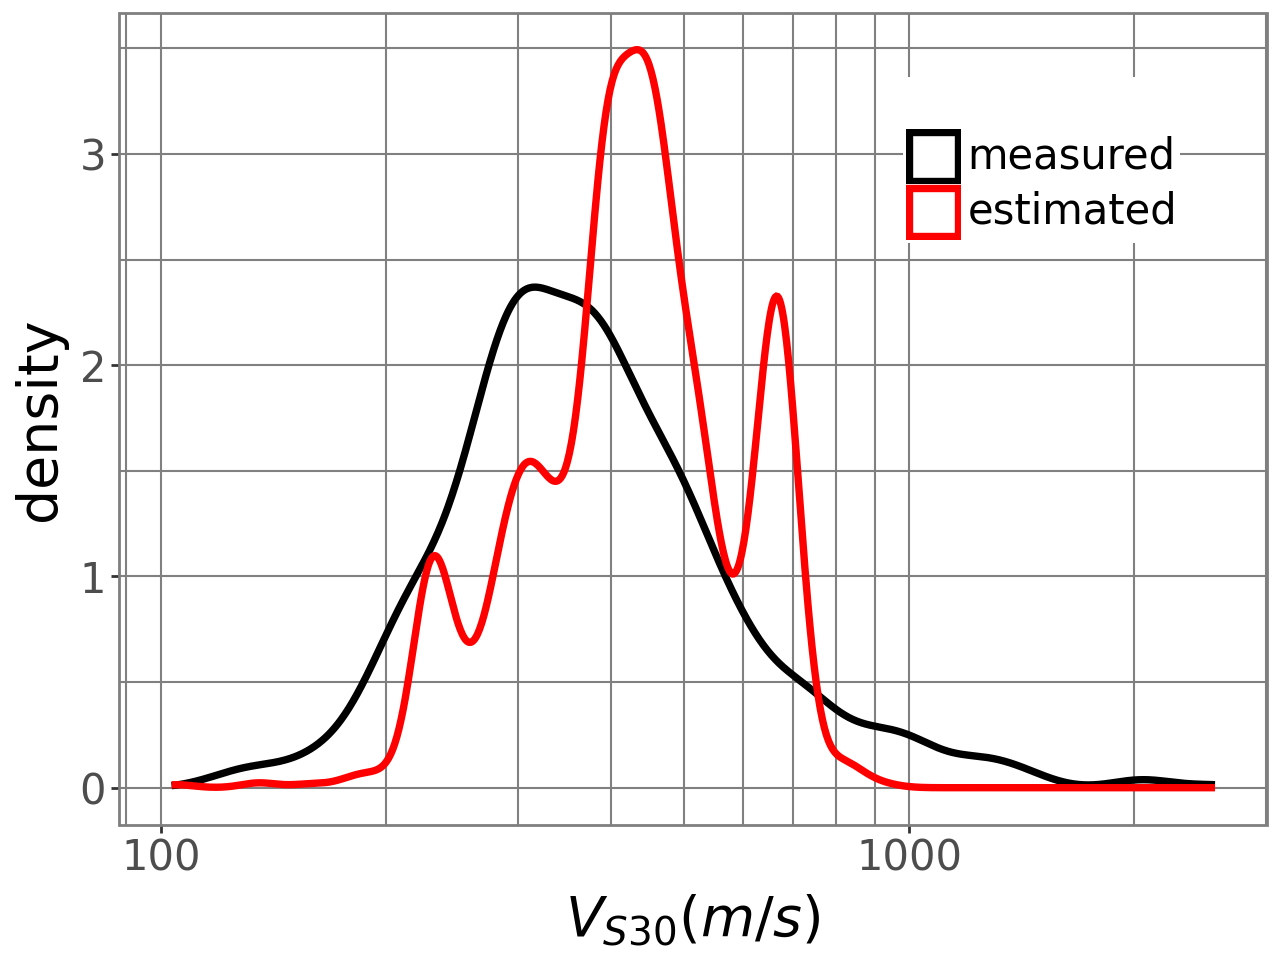

In [ ]:
def plot_vs30_density(data_stat):
    data_stat['vs30_measured'] = pd.Categorical(data_stat['vs30_measured'])
    pl = (ggplot(data_stat, aes(x = 'vs30', color = 'vs30_measured')) +
          geom_density(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks=log_minor_breaks) +
          scale_color_manual(values = ['black', 'red'],
                             labels = ['measured', 'estimated']) +
          labs(y = 'density', x = r'$V_{S30} (m/s)$',
               color = '') +
          custom_theme +
          theme(legend_position='inside',
                legend_position_inside = (0.9,0.9)))
    return pl

pl = plot_vs30_density(data_stat)
# ggsave(pl, os.path.join(dir_plot, 'vs30_density.pdf'),
#                         width = fig_width, height = fig_ratio * fig_width)
pl.show()


## Model inputs

In [ ]:
from ngaw3_kuehnetal27.model_inputs import extract_model_arrays, build_global_dict, setup_nl_model, build_frequency_cholesky
from ngaw3_kuehnetal27.coefficient_sharing import DEFAULT_COEFFICIENT_SHARING

DEFAULT_COEFFICIENT_SHARING

{'c_0': 'dataset_local',
 'c_m1': 'dataset_local',
 'c_m2': 'shared',
 'c_m3': 'shared',
 'c_hw': 'shared',
 'c_nft_1': 'shared',
 'c_nft_2': 'shared',
 'c_nm': 'shared',
 'c_rev': 'shared',
 'c_gs1': 'dataset_local',
 'c_zt': 'dataset_local',
 'c_vs': 'dataset_local',
 'c_attn': 'dataset_local'}

In [ ]:
X_rec, X_eq, X_stat, X_id, Y = extract_model_arrays(data_used, data_eq, data_stat, frequencies_used_names)
global_dict = build_global_dict(data_used_gl, data_eq_gl, data_stat_gl, frequencies_used_names)

In [ ]:
frequencies_used_array = jnp.array(frequencies_used)
nl_model_dict = setup_nl_model("hashash_new", frequencies_used_array)
L_freq = build_frequency_cholesky(frequencies_used)

In [ ]:
coeffs_shared = dict(DEFAULT_COEFFICIENT_SHARING)   # fixed: was mutating the shared default
coeffs_shared['c_nm'] = 'dataset_local'
coeffs_shared['c_rev'] = 'dataset_local'

In [ ]:
data_dict = {
    "F": frequencies_used_array,
    "X_rec": X_rec, "X_eq": X_eq, "X_stat": X_stat, "X_id": X_id, "Y": Y,
    "nl_model_dict": nl_model_dict, "L_freq": L_freq, "global_dict": global_dict,
    "attn_eq": True, "attn_Q": True, "regularize_grad": True,
    "calc_nft": "coeff", "ref_basin_id": 1,
    "estimate_gs_break": True, "estimate_zt_break": True,
    "c0_parametric": True, "cgs1_parametric": True,
    "freq_id_grad": np.arange(len(frequencies_used)),
    "dist_cell": None, "save_f_nl": False,
    "func_gs_scaling": "stafford", "estimate_gs_exp": "fixed",
    "calc_dWS": False, "calc_log_lik": False,
    "sharing_config": coeffs_shared,
    "regularization_sigma": 0.05, "spline_df": 7, "spline_degree": 3,
    "include_mag_unc": None,
}

In [ ]:
from ngaw3_kuehnetal27.documentation import coefficient_table_to_latex, build_coefficient_table

In [ ]:
df = build_coefficient_table(data_dict, coeffs_shared)   # a pandas DataFrame, if you want to inspect/filter first
latex_code = coefficient_table_to_latex(df, caption="...", label="tab:...")
print(latex_code)

\begin{table}[htbp]
\centering
\begin{tabular}{llll}
\toprule
Coefficient & Frequency dependence & Regional & Constraints \\
\midrule
$c_0$ & Parametric (logistic hinge + linear high-frequency term) & Local (separate for WUS \& global) & None \\
$c_{m1}$ & Spline & Local (separate for WUS \& global) & Positive, decreasing in frequency \\
$c_{m2}$ & Spline & Shared (WUS \& global) & Positive, decreasing in frequency \\
$c_{m3}$ & Constant & Shared (always identical for WUS \& global) & Positive \\
$c_{hw}$ & Spline & Shared (WUS \& global) & None \\
$c_{nm}$ & Spline & Local (separate for WUS \& global) & None \\
$c_{rev}$ & Spline & Local (separate for WUS \& global) & None \\
$c_{zt}$ & Spline & Local (separate for WUS \& global) & None \\
$c_{nft,1}$ & Constant (estimated) & Shared (no dataset\_local path implemented) & None \\
$c_{nft,2}$ & Constant (estimated) & Shared (no dataset\_local path implemented) & Positive \\
$c_{gs1}$ & Parametric (logistic hinge) & Local (separate for W

# Prior Predictive

In [ ]:
from gmm_model.numpyro_models import model
from numpyro.infer import Predictive

In [ ]:
input_dict = dict(data_dict)
input_dict['Y'] = None

In [ ]:
n_prior = 100
seed = 5618
prior_predictive = Predictive(model, num_samples=n_prior)
prior_samples = prior_predictive(jax.random.key(seed), **data_dict)

In [ ]:
prior_samples.keys()

dict_keys(['Q_0', 'Q_exp', 'c_0', 'c_0_delta', 'c_0_fb', 'c_0_gl', 'c_0_gl_delta', 'c_0_gl_fb', 'c_0_gl_ic', 'c_0_gl_kappa_star', 'c_0_gl_slope1', 'c_0_gl_slope2', 'c_0_ic', 'c_0_kappa_star', 'c_0_slope1', 'c_0_slope2', 'c_attn_gl', 'c_b_0', 'c_b_1', 'c_b_2', 'c_b_3', 'c_basin', 'c_gs1', 'c_gs1_delta', 'c_gs1_fb', 'c_gs1_gl', 'c_gs1_gl_delta', 'c_gs1_gl_fb', 'c_gs1_gl_ic', 'c_gs1_gl_slope1', 'c_gs1_ic', 'c_gs1_slope1', 'c_hw', 'c_m1', 'c_m1_gl', 'c_m2', 'c_m3', 'c_nft_1', 'c_nft_2', 'c_nm', 'c_nm_gl', 'c_region', 'c_rev', 'c_rev_gl', 'c_vs_est', 'c_vs_gl', 'c_vs_meas', 'c_zt', 'c_zt_gl', 'deltaB', 'deltaB_attn', 'deltaB_attn_gl', 'deltaB_gl', 'deltaS', 'deltaS_gl', 'grad_r1', 'gs_break', 'mu_c_attn_gl', 'mu_c_b_0', 'mu_c_b_1', 'mu_c_b_2', 'mu_c_b_3', 'mu_c_hw', 'mu_c_m1', 'mu_c_m1_gl', 'mu_c_m2', 'mu_c_nm', 'mu_c_nm_gl', 'mu_c_rev', 'mu_c_rev_gl', 'mu_c_vs_est', 'mu_c_vs_gl', 'mu_c_vs_meas', 'mu_c_zt', 'mu_c_zt_gl', 'mu_phi_s2s_est', 'mu_phi_s2s_meas', 'mu_phi_ss_0', 'mu_phi_ss_1', 'mu

# Model Fitting

In [ ]:
from ngaw3_kuehnetal27.numpyro_guides import guide_eas
from ngaw3_kuehnetal27.numpyro_models import model_eas

from ngaw3_kuehnetal27.svi_fitting import run_svi, write_svi_results

In [ ]:
svi_results = run_svi(model_eas, guide_eas, data_dict, num_steps=200_000)

100%|██████████| 200000/200000 [35:49<00:00, 93.03it/s, init loss: 12685391.0000, avg. loss [190001-200000]: 1642442.1250] 


In [ ]:
filestem = 'run1'
write_svi_results(model_eas, guide_eas, svi_results.params, data_dict, dir_results, filestem,
                  frequencies=frequencies_used_array)

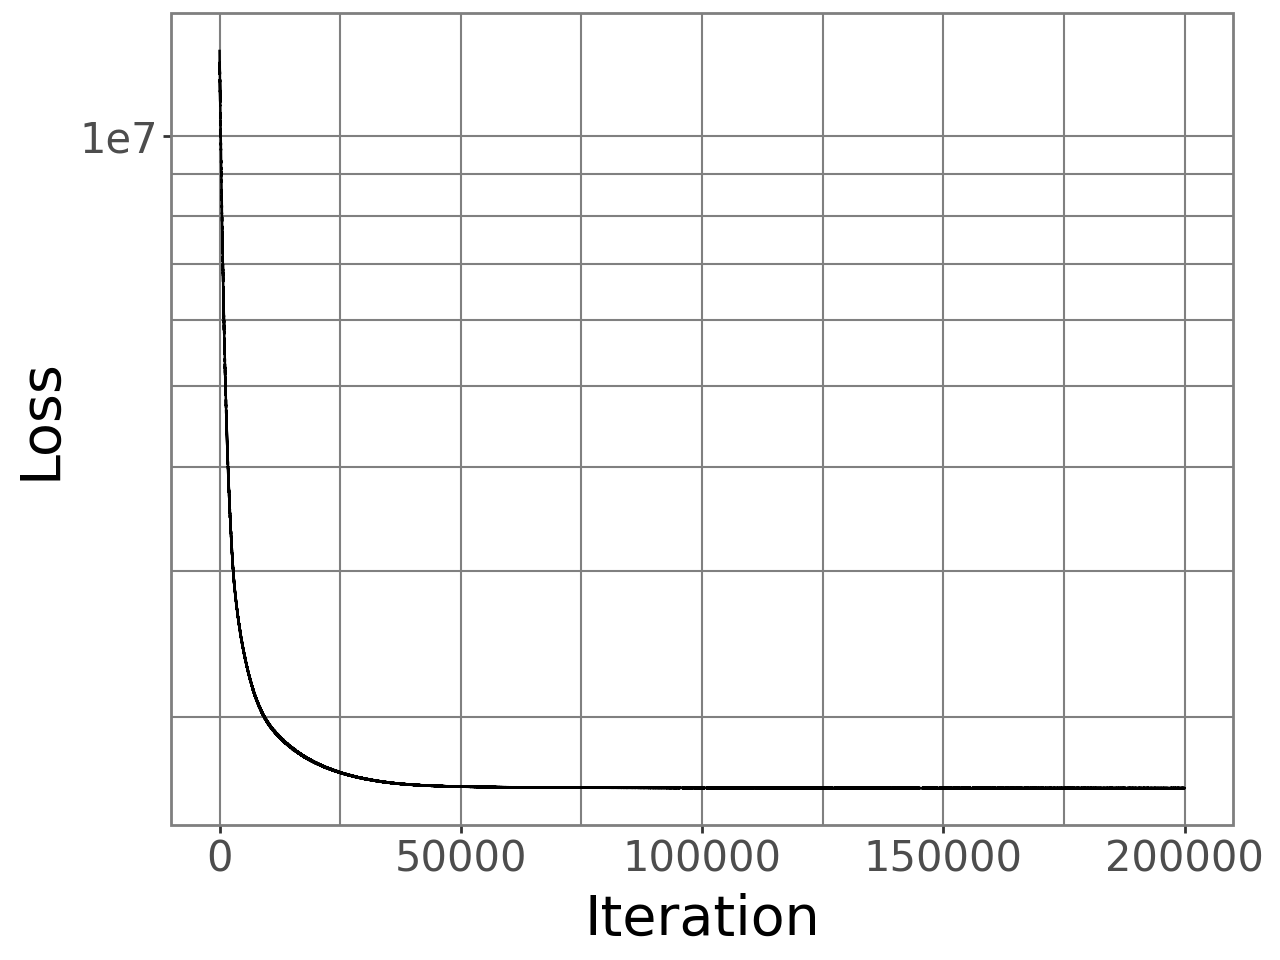

In [ ]:
def plot_loss(svi_results):
    df = pd.DataFrame({'loss':svi_results.losses}).reset_index()
    pl = (ggplot(df, aes(x = 'index', y = 'loss')) +
          geom_line() +
          scale_y_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          labs(x = 'Iteration', y = 'Loss') +
          custom_theme)
    return pl

pl = plot_loss(svi_results)
pl.show()